# Empirical Kyle (1985) Price Impact in Crypto  
### (Coinbase BTC–USD)

## Goal

Kyle (1985) implies a linear price impact relation in which market makers update prices based on total order flow.

In reduced-form empirical implementation, we estimate:

$$
\Delta m_t = \alpha + \Lambda Q_t + \varepsilon_t
$$

where:

- $m_t = \log(P_t)$ is the log-price (proxy for the equilibrium transaction price),
- $Q_t$ is signed order flow (net buy volume minus sell volume) within a short time interval,
- $\Lambda$ is **Kyle’s lambda**, the price impact coefficient (inverse market depth),
- $\varepsilon_t$ captures residual price movements not explained by order flow.

---

## Empirical Strategy

This notebook proceeds as follows:

1. **Download high-frequency trade data** from Coinbase.
2. **Construct signed order flow** $Q_t$ as the empirical analogue of total order flow.
3. **Aggregate trades into 1-second intervals** to approximate short-horizon price formation.
4. **Compute log price changes** $\Delta m_t$.
5. **Estimate $\Lambda$** using OLS with HAC (Newey–West) standard errors.
6. **Conduct diagnostics and robustness tests**, including:
   - Alternative bar sizes (1s, 5s, 10s, etc.)
   - Rolling lambda estimation
   - Volatility regime comparisons

In [1]:
pip install pandas numpy requests statsmodels matplotlib

In [7]:
PRODUCT = "BTC-USD"     # change to ETH-USD if you want
N_PAGES = 20            # each page ~100 trades; increase for more observations

In [6]:
import requests
import pandas as pd
import numpy as np
import statsmodels.api as sm

PRODUCT = "BTC-USD"   # or "ETH-USD"
N_PAGES = 15          # more pages = more trades (start with 10-30)

def coinbase_trades(product=PRODUCT, n_pages=10):
    """
    Coinbase public endpoint. Returns recent trades.
    Each page returns up to 100 trades.
    """
    url = f"https://api.exchange.coinbase.com/products/{product}/trades"
    out = []
    after = None

    headers = {"User-Agent": "microstructure-research"}  # helps avoid 403 sometimes

    for _ in range(n_pages):
        params = {"limit": 100}
        if after is not None:
            params["after"] = after

        r = requests.get(url, params=params, headers=headers, timeout=30)
        r.raise_for_status()

        data = r.json()
        if not data:
            break

        out.extend(data)

        # pagination cursor: Coinbase returns "cb-after" header
        after = r.headers.get("cb-after")
        if after is None:
            break

    df = pd.DataFrame(out)
    # Fields: time (ISO), price, size, side ("buy"/"sell")
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df["price"] = df["price"].astype(float)
    df["size"] = df["size"].astype(float)
    df["sign"] = np.where(df["side"].str.lower().eq("buy"), 1.0, -1.0)
    df["signed_size"] = df["sign"] * df["size"]

    df = df.sort_values("time")
    return df[["time", "price", "size", "signed_size", "side"]]

trades = coinbase_trades(PRODUCT, N_PAGES)
print(trades.head(), "\n", trades.tail())

# Build 1-second bars: signed order flow Q and last price as proxy for mid/price
bar = "1s"
t = trades.set_index("time").sort_index()

bars = pd.DataFrame({
    "Q": t["signed_size"].resample(bar).sum(),
    "last_price": t["price"].resample(bar).last(),
    "vol": t["size"].resample(bar).sum()
}).dropna()

# Use log-price changes
bars["m"] = np.log(bars["last_price"])
bars["dm"] = bars["m"].diff()
bars = bars.dropna()

# Kyle regression: dm_t = alpha + Lambda * Q_t + eps_t
Y = bars["dm"].values
X = sm.add_constant(bars["Q"].values)
res = sm.OLS(Y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

print(res.summary())
print("\nEstimated Kyle lambda (Lambda) =", res.params[1])

                                 time     price      size  signed_size  side
1499 2026-02-27 10:15:31.991491+00:00  66876.82  0.000613    -0.000613  sell
1495 2026-02-27 10:15:31.991491+00:00  66877.32  0.049584    -0.049584  sell
1498 2026-02-27 10:15:31.991491+00:00  66876.89  0.035904    -0.035904  sell
1497 2026-02-27 10:15:31.991491+00:00  66877.00  0.013599    -0.013599  sell
1496 2026-02-27 10:15:31.991491+00:00  66877.17  0.000299    -0.000299  sell 
                                time     price      size  signed_size  side
11 2026-02-27 10:19:22.424215+00:00  67035.01  0.013390    -0.013390  sell
7  2026-02-27 10:19:22.424215+00:00  67036.00  0.053163    -0.053163  sell
2  2026-02-27 10:19:22.499096+00:00  67035.01  0.000373     0.000373   buy
1  2026-02-27 10:19:22.499096+00:00  67035.00  0.000017     0.000017   buy
0  2026-02-27 10:19:22.499096+00:00  67035.00  0.000007     0.000007   buy
                            OLS Regression Results                            
Dep. Va

### First step, Why we download trade-level data

Kyle’s model is built around order flow.

In real markets, the only observable proxy for order flow is signed trade volume.

Therefore, we use trade-level data to reconstruct:

The signed order flow within interval $t$ is defined as:

$$
Q_t = \sum_{i \in t} \text{signed volume}_i
$$

Equivalently,

$$
Q_t = \sum_{i \in t} \text{sign}_i \cdot \text{size}_i
$$

where:
- $\text{sign}_i = +1$ for buy-initiated trades  
- $\text{sign}_i = -1$ for sell-initiated trades  
- $\text{size}_i$ is the trade quantity  

This quantity represents net order flow within interval $t$ and serves as the empirical analogue of Kyle’s total order flow:

$$
Y = x + u
$$
which is the empirical analogue of total order flow \(Y = x + u\).

## Step 2: Trade data and the microstructure interpretation

In Kyle (1985), the key sufficient statistic observed by market makers is **total order flow**:
\[
Y = x + u
\]
We cannot separate informed \(x\) and noise \(u\) in real markets, so we use **signed trade volume** as a proxy for net order flow.

Coinbase provides the trade aggressor side as `side`:
- `buy` = buyer initiated (aggressive buy) ⇒ positive sign
- `sell` = seller initiated (aggressive sell) ⇒ negative sign

We construct signed order flow within each interval $t$ as:

$$
Q_t = \sum_{i \in t} \text{sign}_i \cdot \text{size}_i
$$

where:

- $\text{sign}_i = +1$ for buy-initiated trades  
- $\text{sign}_i = -1$ for sell-initiated trades  
- $\text{size}_i$ is the trade quantity  

This is the empirical analogue of Kyle’s total order flow:

$$
Y = x + u
$$

In the model, $Y$ represents net order flow (informed plus noise trading).  
In the data, $Q_t$ serves as its observable proxy within each short time interval $t$
## Interpretation of the Kyle Regression

## Estimation of the Reduced-Form Kyle (1985) Equation

We estimate the reduced-form Kyle (1985) price impact equation:

$$
\Delta m_t = \alpha + \Lambda Q_t + \varepsilon_t
$$

### Interpretation of each component:

- $Q_t$: empirical proxy for total order flow  
  $$
  Y = x + u
  $$
  where $x$ represents informed trading and $u$ represents noise trading.

- $\Delta m_t$: log price change over a 1-second interval, defined as  
  $$
  \Delta m_t = \log(P_t) - \log(P_{t-1})
  $$

- $\Lambda$: Kyle’s price impact coefficient (inverse market depth).  
  A larger $|\Lambda|$ implies greater price sensitivity to order flow.

- $\varepsilon_t$: residual price movement not explained by order flow.

---

### Inference

We estimate the regression using HAC (Newey–West) standard errors with 5 lags.  
This corrects for:

- Heteroskedasticity  
- Serial correlation  

which are typical features of high-frequency financial data.
---



## What We Did in Code

1. **Downloaded trade-level data** from Coinbase to observe real-time transaction flow.

2. **Constructed signed order flow** within each interval:

   $$
   Q_t = \sum_{i \in t} \text{sign}_i \cdot \text{size}_i
   $$

   where:
   - $\text{sign}_i = +1$ for buy-initiated trades  
   - $\text{sign}_i = -1$ for sell-initiated trades  

   This serves as the empirical analogue of total order flow  
   $$
   Y = x + u
   $$
   in the Kyle (1985) model.


# Step 3: Aggregation into Short Time Intervals

**Aggregated trades into 1-second intervals** to approximate short-horizon price updating
Kyle’s model describes price formation at short horizons.

To approximate sequential price updating, we aggregate trades into 1-second intervals.

For each interval $t$, we compute:

- $Q_t$ — net signed order flow
- $P_t$ — last transaction price in the interval
- Total traded volume

Short intervals isolate microstructure effects and reduce contamination from slower-moving macro factors.


# Step 4: Construction of Log Price Changes
**Computed log price changes:**

   $$
   \Delta m_t = \log(P_t) - \log(P_{t-1})
   $$
We define log-price as:

$$
m_t = \log(P_t)
$$

and log returns as:

$$
\Delta m_t = \log(P_t) - \log(P_{t-1})
$$

Log differences are used because:

- Price levels are non-stationary,
- Returns are approximately stationary,
- Microstructure price impact is naturally modeled in return space.

This allows us to estimate the reduced-form price impact relation.

## Step 5: Estimation of the Reduced-Form Kyle Equation

We estimate the regression:

$$
\Delta m_t = \alpha + \Lambda Q_t + \varepsilon_t
$$

where:

- $\Delta m_t$ is the log price change,
- $Q_t$ is signed order flow,
- $\Lambda$ is Kyle’s price impact coefficient,
- $\varepsilon_t$ captures unexplained price movements.

The coefficient $\Lambda$ measures the price change per unit net order flow.

A statistically significant $\Lambda$ implies:

- Price responds systematically to order flow,
- Order flow contains information about asset value,
- Market behavior is consistent with Kyle-type microstructure.

---

## Interpretation of Results

The estimated coefficient $\Lambda$ measures the **price change per unit of net signed order flow**.

A statistically significant $\Lambda$ implies:

- Price responds systematically to signed order flow.
- Order flow contains information about asset value.
- The crypto market exhibits behavior consistent with Kyle-type microstructure.

---

## Market Depth Interpretation

Market depth is inversely related to price impact:

$$
\text{Market Depth} = \frac{1}{|\Lambda|}
$$

- A small $|\Lambda|$ implies a deep, liquid market.
- A large $|\Lambda|$ implies a shallow market with stronger price impact.

note

High-frequency financial data typically exhibit:

- Heteroskedasticity (time-varying volatility),
- Serial correlation (price clustering and order flow persistence).

To ensure valid statistical inference, we estimate the regression using
HAC (Newey–West) standard errors with 5 lags.

This correction ensures that:

- Test statistics for $\Lambda$ are reliable,
- Statistical significance is not overstated,
- Inference accounts for microstructure dynamics.

Visual diagnostic (Δm vs Q)
## Step 6: Visual diagnostic of Kyle price impact

Kyle’s reduced-form implication is that short-horizon price changes co-move with signed order flow:

$$
\Delta m_t = \alpha + \Lambda Q_t + \varepsilon_t
$$

A scatter plot of \(\Delta m_t\) vs \(Q_t\) should show a roughly linear tendency.  
This is not expected to be “tight” because microstructure noise is large at 1-second frequency, but the slope should be consistent with \(\hat{\Lambda}\).

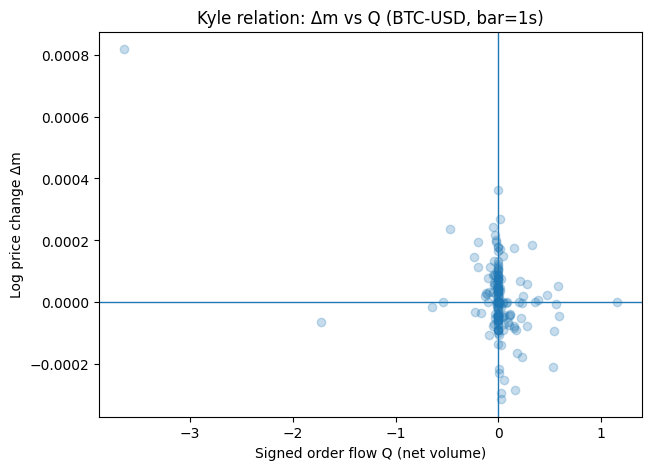

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(bars["Q"], bars["dm"], alpha=0.25)
plt.xlabel("Signed order flow Q (net volume)")
plt.ylabel("Log price change Δm")
plt.title(f"Kyle relation: Δm vs Q ({PRODUCT}, bar={bar})")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.show()

# Step 6 Explanation: Visual Diagnostic — Price Changes vs Order Flow

The scatter plot displays the empirical relationship:

$$
\Delta m_t = \alpha + \Lambda Q_t + \varepsilon_t
$$

Each point represents one 1-second interval.

- Horizontal axis: signed order flow $Q_t$
- Vertical axis: log price change $\Delta m_t$

### What this shows:

If Kyle’s model holds, positive net buying pressure should be associated with positive price changes, and negative selling pressure should be associated with price decreases.

Although high-frequency data are noisy, the overall slope of the cloud reflects the estimated price impact coefficient $\Lambda$.

The dispersion around zero reflects:

- Microstructure noise
- Bid–ask bounce
- Unexplained price variation

in the figure:

Points are concentrated near zero (normal in HF data).

There is dispersion because most price moves are noise.

But the regression slope is statistically significant.
The existence of a statistically significant slope confirms that price systematically responds to order flow.

## Step 7: Robustness to sampling frequency (1s, 5s, 10s, 30s)

Kyle impact should exist across short horizons, but its estimated magnitude may change because:
- at very high frequency, bid–ask bounce and discreteness matter more
- at longer intervals, more noise/information arrives and effects average out

We re-estimate $\Lambda$ across multiple bar sizes and compare.

In [9]:
def estimate_lambda_for_bar(trades_df, bar_size="1s", hac_lags=5):
    t = trades_df.set_index("time").sort_index()
    b = pd.DataFrame({
        "Q": t["signed_size"].resample(bar_size).sum(),
        "last_price": t["price"].resample(bar_size).last(),
        "vol": t["size"].resample(bar_size).sum()
    }).dropna()

    b["m"] = np.log(b["last_price"])
    b["dm"] = b["m"].diff()
    b = b.dropna()

    Y = b["dm"].values
    X = sm.add_constant(b["Q"].values)
    fit = sm.OLS(Y, X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})

    return {
        "bar": bar_size,
        "N": len(b),
        "lambda": float(fit.params[1]),
        "p_value": float(fit.pvalues[1]),
        "R2": float(fit.rsquared)
    }

results = []
for bsize in ["1s", "5s", "10s", "30s"]:
    results.append(estimate_lambda_for_bar(trades, bsize, hac_lags=5))

robust_tbl = pd.DataFrame(results)
robust_tbl

,bar,N,lambda,p_value,R2
0,1s,183,-0.000156,0.002377,0.218478
1,5s,46,-0.000154,0.000001,0.194008
2,10s,23,-0.000137,0.000525,0.161313
3,30s,7,-0.000099,0.000160,0.051889


# Step 7 explanation: Robustness Across Sampling Frequencies

We re-estimate the Kyle regression using different time aggregations (1s, 5s, 10s, 30s).

Why?

Kyle’s model describes short-horizon price formation.  
If the price impact coefficient $\Lambda$ is stable across short intervals, it indicates that the result reflects genuine microstructure behavior rather than statistical artifacts.

As aggregation increases:

- Microstructure noise is averaged out,
- Other information may enter,
- The magnitude of $\Lambda$ may decline.

Stability across 1s–10s intervals strengthens the empirical validity of the result.

## Step 8: Time-Varying Liquidity — Rolling Lambda

The basic Kyle model assumes a constant price impact coefficient.

In real markets, liquidity fluctuates due to:

- Volatility shocks
- Order book depth changes
- Inventory risk of liquidity providers

We estimate a rolling regression to compute a time-varying:

$$
\Lambda_t
$$

This allows us to observe how price impact evolves through time.

Interpretation:

- Rising $|\Lambda_t|$ indicates worsening liquidity.
- Falling $|\Lambda_t|$ indicates improved market depth.

This extends the static Kyle framework into a dynamic liquidity analysis.

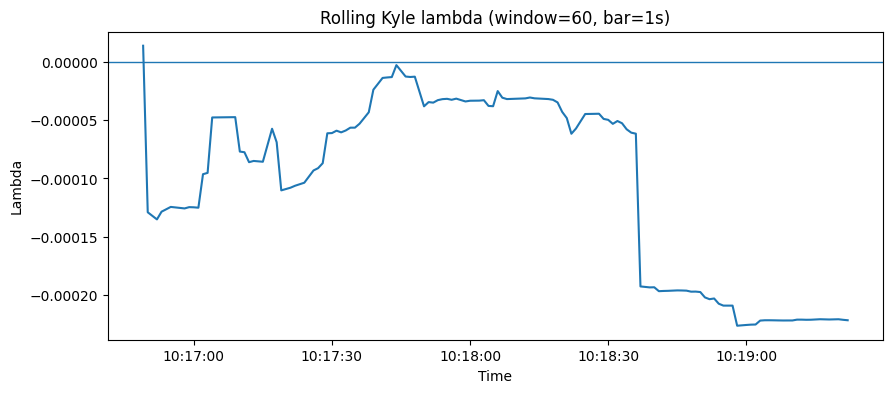

Rolling lambda summary:
count    123.000000
mean      -0.000106
std        0.000078
min       -0.000227
25%       -0.000197
50%       -0.000069
75%       -0.000038
max        0.000014
dtype: float64


In [10]:
def rolling_lambda(bars_df, window=60):
    # Simple rolling OLS (no HAC inside the roll to keep it lightweight)
    lam = []
    idx = bars_df.index

    for i in range(window, len(bars_df)):
        sub = bars_df.iloc[i-window:i]
        Y = sub["dm"].values
        X = sm.add_constant(sub["Q"].values)
        fit = sm.OLS(Y, X).fit()
        lam.append(fit.params[1])

    return pd.Series(lam, index=idx[window:])

roll = rolling_lambda(bars, window=60)

plt.figure(figsize=(10,4))
plt.plot(roll)
plt.title(f"Rolling Kyle lambda (window=60, bar={bar})")
plt.xlabel("Time")
plt.ylabel("Lambda")
plt.axhline(0, linewidth=1)
plt.show()

print("Rolling lambda summary:")
print(roll.describe())

## Step 9: Volatility Regimes and Price Impact

Market microstructure theory predicts that price impact increases during volatile periods.

When volatility rises:

- Liquidity providers face higher risk,
- Order book depth declines,
- Price sensitivity to order flow increases.

We divide the sample into high- and low-volatility regimes and estimate $\Lambda$ separately.

If:

$$
|\Lambda_{\text{high vol}}| > |\Lambda_{\text{low vol}}|
$$

this confirms that liquidity deteriorates during stressed market conditions.

In [12]:
bars2 = bars.copy()
bars2["volatility"] = bars2["dm"].rolling(60).std()
bars2 = bars2.dropna()

med = bars2["volatility"].median()
low = bars2[bars2["volatility"] <= med]
high = bars2[bars2["volatility"] > med]

def estimate_lambda_from_bars(bdf, hac_lags=5):
    Y = bdf["dm"].values
    X = sm.add_constant(bdf["Q"].values)
    fit = sm.OLS(Y, X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    return fit

fit_low = estimate_lambda_from_bars(low, hac_lags=5)
fit_high = estimate_lambda_from_bars(high, hac_lags=5)

print("LOW volatility regime:")
print("  N =", len(low))
print("  lambda =", float(fit_low.params[1]), "p =", float(fit_low.pvalues[1]))

print("\nHIGH volatility regime:")
print("  N =", len(high))
print("  lambda =", float(fit_high.params[1]), "p =", float(fit_high.pvalues[1]))

print("\nCompare |lambda|:")
print("  |lambda_low|  =", abs(float(fit_low.params[1])))
print("  |lambda_high| =", abs(float(fit_high.params[1])))

LOW volatility regime:
  N = 62
  lambda = -4.8342655096167795e-05 p = 0.09534894729557146

HIGH volatility regime:
  N = 62
  lambda = -0.0002292597462191127 p = 1.4512108547904525e-196

Compare |lambda|:
  |lambda_low|  = 4.8342655096167795e-05
  |lambda_high| = 0.0002292597462191127


## Interpretation of Volatility Regime Results

We estimate the Kyle price impact coefficient separately for low- and high-volatility periods.

The results show:

$$
\Lambda_{low} = -4.83 \times 10^{-5}
$$

$$
\Lambda_{high} = -2.29 \times 10^{-4}
$$

### Key Findings

- The magnitude of price impact is substantially larger during high-volatility periods:
  
  $$
  |\Lambda_{high}| \gg |\Lambda_{low}|
  $$

- The high-volatility $\Lambda$ is highly statistically significant.
- The low-volatility $\Lambda$ is smaller and only weakly significant.

### Economic Interpretation

During volatile market conditions:

- Liquidity providers face greater risk.
- Order book depth declines.
- Prices become more sensitive to order flow.

Since market depth is defined as:

$$
\text{Market Depth} = \frac{1}{|\Lambda|}
$$

a larger $|\Lambda|$ implies lower market depth.

Thus, the results indicate that the market becomes significantly less liquid during high-volatility periods, consistent with microstructure theory.

## Optional Step 10: Results table (for LaTeX)

We collect the main estimated \(\Lambda\), p-value, and R² in a clean table to paste into the final report.

In [11]:
main_fit = res  # from your Step 5 regression

summary_tbl = pd.DataFrame({
    "Metric": ["Lambda", "p-value (Lambda)", "R-squared", "N observations"],
    "Value": [float(main_fit.params[1]), float(main_fit.pvalues[1]), float(main_fit.rsquared), int(main_fit.nobs)]
})
summary_tbl

,Metric,Value
0,Lambda,-0.000156
1,p-value (Lambda),0.002377
2,R-squared,0.218478
3,N observations,183.000000


Co-Pilot aided me in structuring and writing some of the code, all the processes veried by me and consultation through ny lecture notes